# 1. Definición del objetivo
**Objetivo:** desarrollar un modelo que permita clasificar una flor Iris en una de tres especies a partir de las medidas de sus sépalos y pétalos.

Las tres clases son:

* Iris setosa
* Iris versicolor
* Iris virginica

¿Qué tarea de minería de datos tenemos? **Clasificación**

# 2. Selección de datos

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

iris = load_iris()

# Crear DataFrame con las características
X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Crear variable objetivo
y = pd.Series(
    iris.target,
    name="species"
)

# Conocer el dataset
print("Dimensiones de X:", X.shape)

print("\nCaracterísticas:")
print(X.columns)

print("\nClases:")
print(np.unique(iris.target))

Dimensiones de X: (150, 4)

Características:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

Clases:
[0 1 2]


In [ ]:
print("\nNombres de las clases:")
print(iris.target_names)


Nombres de las clases:
['setosa' 'versicolor' 'virginica']


In [ ]:
# DataFrame completo para visualización
df = X.copy()

df["species"] = y.map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


# 3. Limpieza

In [ ]:
# Verificar si hay valores faltantes
print("Valores faltantes:")
print(X.isnull().sum())

Valores faltantes:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [ ]:
# Verificar si hay desbalnce de clases
print(y.value_counts())

species
0    50
1    50
2    50
Name: count, dtype: int64


In [ ]:
for i, nombre in enumerate(iris.target_names):
    print(nombre, ":", (y == i).sum())

setosa : 50
versicolor : 50
virginica : 50


In [ ]:
# División del dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (120, 4)
Datos de prueba: (30, 4)


# 4. Normalización

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#5. Minería de datos

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

modelo = KNeighborsClassifier(n_neighbors=5)

modelo.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = modelo.predict(X_test_scaled)

# 6. Evaluación

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9666666666666667


In [ ]:
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 96.67%


#7. Interpretación

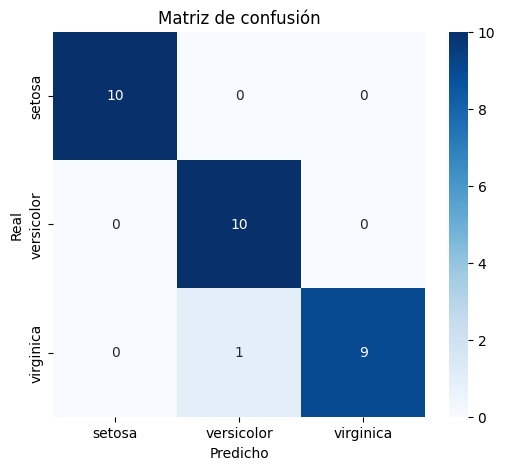

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Graficar
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión")

plt.show()

El modelo desarrollado logró clasificar correctamente 29 de las 30 flores evaluadas, obteniendo una exactitud aproximada del 96.67 %. La matriz de confusión muestra que únicamente una observación fue asignada a una especie incorrecta. Los resultados indican que el modelo presenta un alto desempeño para distinguir entre las tres especies de Iris utilizando las características de longitud y ancho de sépalo y pétalo.

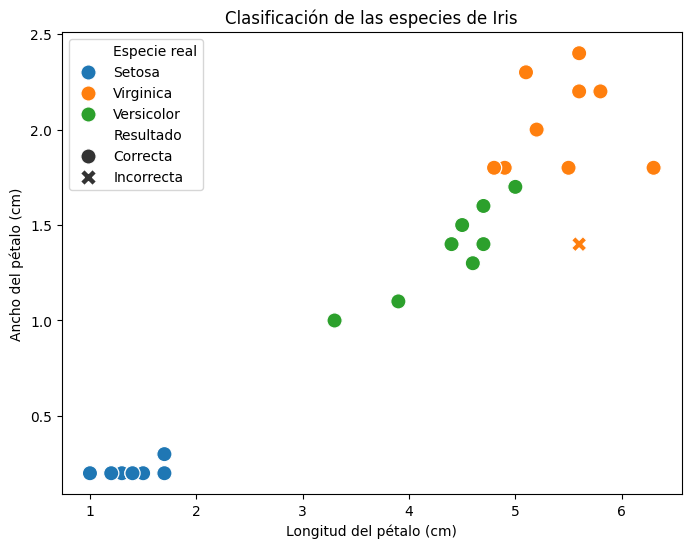

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Crear dataframe para visualización
resultados = X_test.copy()

resultados["Especie real"] = y_test.map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

resultados["Predicción"] = pd.Series(
    y_pred,
    index=X_test.index
).map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

# Identificar predicciones correctas e incorrectas
resultados["Resultado"] = (
    resultados["Especie real"] == resultados["Predicción"]
).map({
    True: "Correcta",
    False: "Incorrecta"
})

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=resultados,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="Especie real",
    style="Resultado",
    s=120
)

plt.xlabel("Longitud del pétalo (cm)")
plt.ylabel("Ancho del pétalo (cm)")
plt.title("Clasificación de las especies de Iris")

plt.show()